# Laboratorium 4 - Aktor–krytyk

### utils

In [56]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os

def plot_image_matrix(image_matrix, figsize=(12, 8), wspace=0., hspace=0.):
    """
    Plots a grid of images from a 2D array of file paths.

    Parameters:
    - image_matrix: 2D list or ndarray containing paths to images.
    - figsize: Tuple representing the overall figure size (width, height).
    - wspace: Padding between columns.
    - hspace: Padding between rows.
    """
    # Convert to a NumPy array to easily grab the shape
    matrix = np.array(image_matrix)

    # If the user passes a flat 1D array by mistake, convert it to 1 row
    if matrix.ndim == 1:
        matrix = matrix.reshape(1, -1)

    rows, cols = matrix.shape

    # Create the grid
    fig, axes = plt.subplots(rows, cols, figsize=figsize)

    # Matplotlib's axes array behaves weirdly with 1D. We force it to be 2D
    # so we can always index it with axes[i, j].
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes[np.newaxis, :]
    elif cols == 1:
        axes = axes[:, np.newaxis]

    # Apply the padding between rows and columns
    plt.subplots_adjust(wspace=wspace, hspace=hspace)

    # Loop through the rows and columns to plot each image
    for i in range(rows):
        for j in range(cols):
            ax = axes[i, j]
            img_path = matrix[i, j]

            # Hide the axes ticks and borders for a clean look
            ax.axis('off')

            # Check if the path is valid and exists
            if img_path and os.path.exists(img_path):
                try:
                    img = mpimg.imread(img_path)
                    ax.imshow(img)
                except Exception as e:
                    ax.text(0.5, 0.5, f"Error reading file",
                            ha='center', va='center', transform=ax.transAxes)
            else:
                # If there is an empty string/None, just leave the spot blank
                if img_path:
                    ax.text(0.5, 0.5, "File not found",
                            ha='center', va='center', transform=ax.transAxes)

    # Display the final matrix
    plt.show()


## CartPole

#### Strata (TD, krytyk, aktor, entropia)

W `compute_loss`:

- **Cel TD:** R + γ·(1 − terminated)·V(s′), przy czym V(s′) ma **`stop_gradient`** — inaczej krytyk mógłby „oszukiwać" obniżając wartość następnego stanu zamiast dopasowywać V(s) do rzeczywistego sygnału.
- **Błąd** δ = target − V(s); strata krytyka δ².
- **Aktor:** −stop_gradient(δ)·log π(a|s) — gradient polityki; **`stop_gradient` na δ** zapobiega temu, by aktor manipulował wagami krytyka zamiast poprawiać zachowanie.
- **Entropia:** dla CartPole w konfiguracji domyślnej β = 0, więc bonus entropii nie zmienia uczenia.

#### Architektura ze wspólnymi wagami

Funkcja `build_actor_critic` buduje jedną gałąź `fc1` → `fc2` z aktywacją `tanh`, a na końcu rozdziela się na **logity** akcji (bez softmax w sieci) oraz **wartość stanu** `V(s)` z liniową warstwą wyjściową. Softmax i log-prawdopodobieństwa liczymy w stracie numerycznie (log-sum-exp).

```python
def build_actor_critic(obs_dim, n_actions, hidden=(256, 256)) -> keras.Model:
    obs = keras.Input(shape=(obs_dim,), name="obs")
    x = keras.layers.Dense(hidden[0], activation="tanh", name="fc1")(obs)
    x = keras.layers.Dense(hidden[1], activation="tanh", name="fc2")(x)
    logits = keras.layers.Dense(n_actions, name="logits")(x)
    value = keras.layers.Dense(1, name="value")(x)
    return keras.Model(inputs=obs, outputs=[logits, value], name="ActorCritic")
```

Wybór akcji w `choose_action`: inferencja `model(x, training=False)`, `keras.ops.softmax` na logitach, konwersja do NumPy, normalizacja i losowanie `np.random.choice` — polityka jest stochastyczna zgodnie z rozkładem π(a|s).

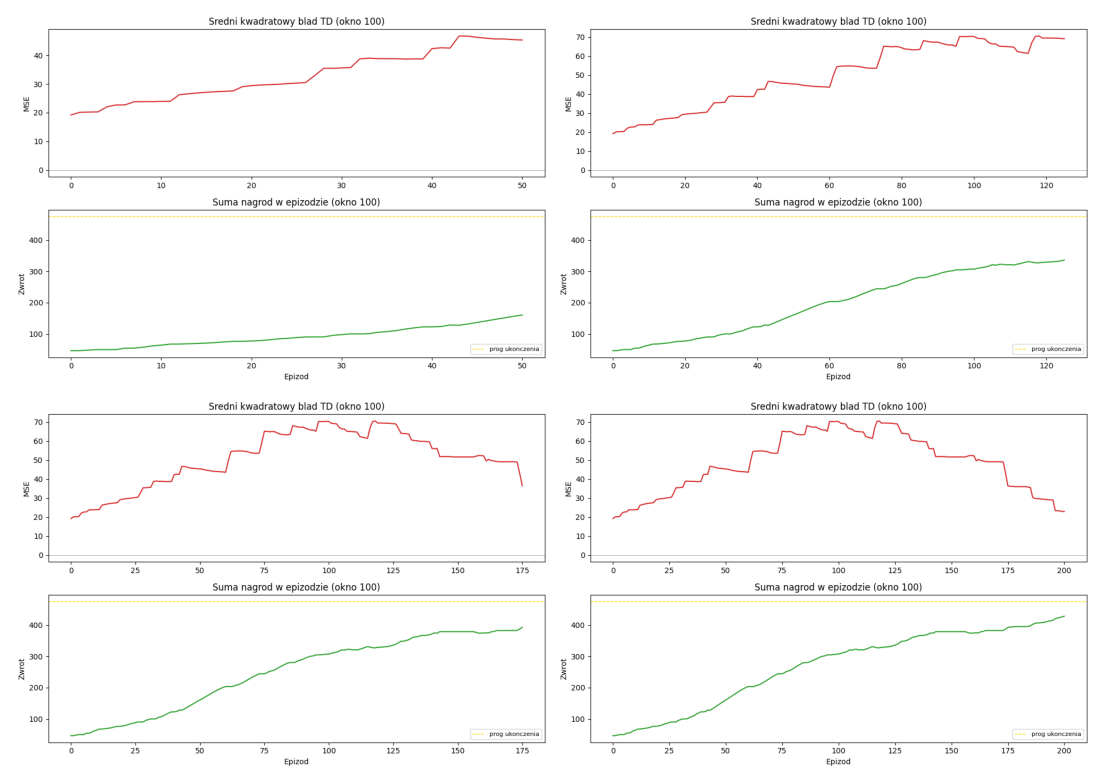

In [57]:
prefix = "cartpole_single_network/plots_cartpole"

episodes_grid = [
    [150, 225],
    [275, 300],
]
img_matrix = [[f"{prefix}/learning_{ep:05d}.png" for ep in row] for row in episodes_grid]

plot_image_matrix(img_matrix, figsize=(14, 10))

#### Architektura z rozłącznymi wagami


`build_actor_critic_separate` konstruuje model aktor–krytyk tak, że **aktor i krytyk mają osobne dwie warstwy ukryte** (`actor_fc1`→`actor_fc2`→`logits` oraz `critic_fc1`→`critic_fc2`→`value`), wyłącznie od tego samego wejścia `obs`. Nie ma współdzielenia wag między gałęziami — parametrów jest około dwa razy więcej niż przy jednym trzonie; wartości `hidden[0]` i `hidden[1]` oznaczają wyłącznie szerokości kolejnych warstw w każdej ścieżce. Wyjścia to nadal `[logits, value]` (softmax i uczenie odbywają się jak wcześniej w `compute_loss` / `choose_action`).

```python
def build_actor_critic_separate(
    obs_dim: int,
    n_actions: int,
    hidden: tuple[int, int] = (256, 256),
) -> keras.Model:
    """
    Actor-Critic z NIEZALEZNYMI trzonkami — brak wspoldzielonych wag.
    Kazda glowica ma wlasne dwie warstwy ukryte (dwa razy wiecej parametrow).
    """
    obs = keras.Input(shape=(obs_dim,), name="obs")

    xa = keras.layers.Dense(hidden[0], activation="tanh", name="actor_fc1")(obs)
    xa = keras.layers.Dense(hidden[1], activation="tanh", name="actor_fc2")(xa)
    logits = keras.layers.Dense(n_actions, name="logits")(xa)

    xc = keras.layers.Dense(hidden[0], activation="tanh", name="critic_fc1")(obs)
    xc = keras.layers.Dense(hidden[1], activation="tanh", name="critic_fc2")(xc)
    value = keras.layers.Dense(1, name="value")(xc)

    return keras.Model(inputs=obs, outputs=[logits, value], name="ActorCriticSeparate")
```


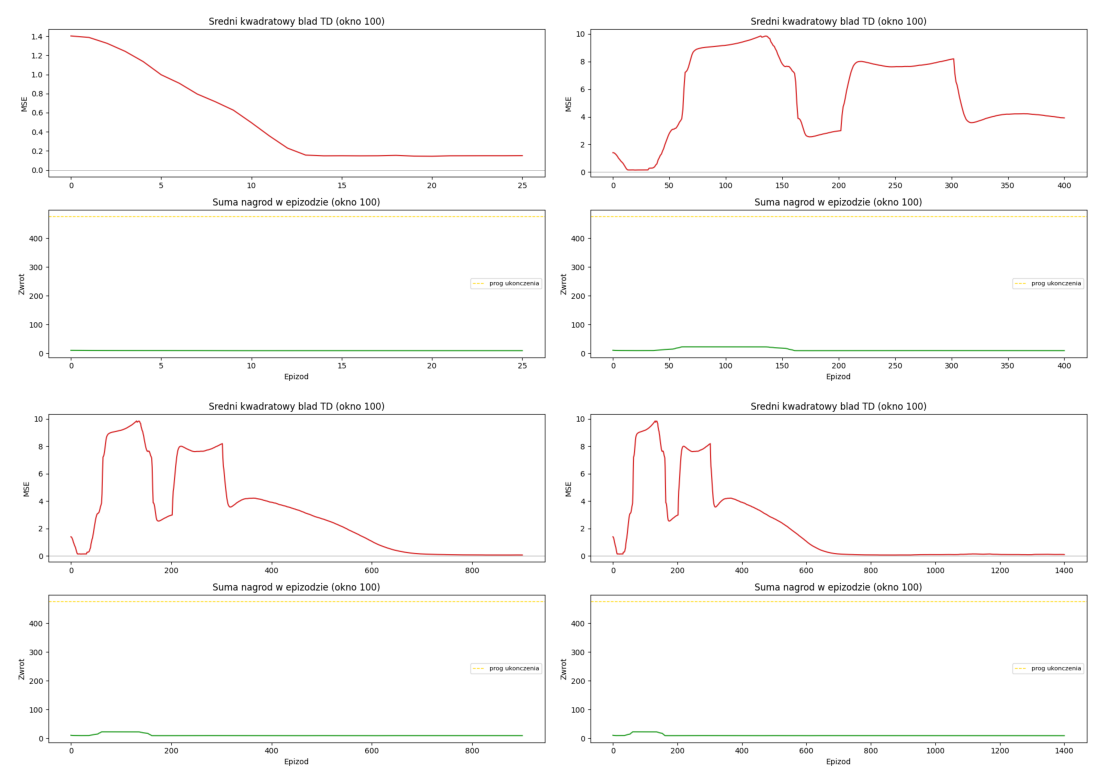

In [58]:
prefix = "cartpole_separate_networks/plots_cartpole"
episodes_grid = [
    [125, 500],
    [1000, 1500],
]
img_matrix = [[f"{prefix}/learning_{ep:05d}.png" for ep in row] for row in episodes_grid]

plot_image_matrix(img_matrix, figsize=(14, 10))

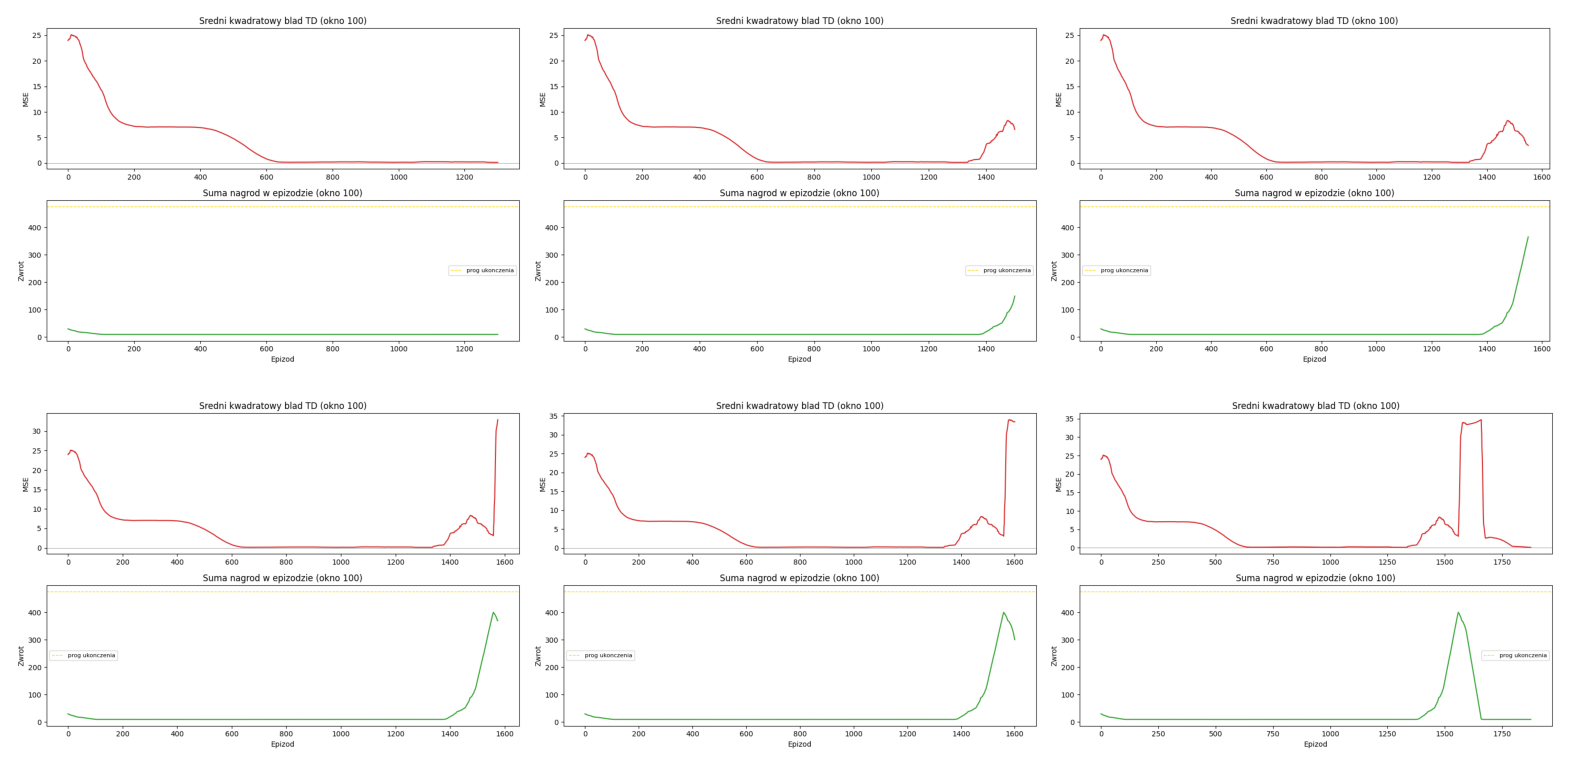

In [76]:
prefix = "cartpole_separete_networks_2\\plots_cartpole"
episodes_grid = [
    [1400, 1600, 1650],
    [1675, 1700, 1975],
]
img_matrix = [[f"{prefix}\\learning_{ep:05d}.png" for ep in row] for row in episodes_grid]
plot_image_matrix(img_matrix, figsize=(20, 10))

Jak widać trenowanie jest niestabilne, ale przy 2 runie nagroda zaczęła wzracać dlatego zrestartowanem uczenie od tego momentu

(cartpole_separete_networks_2\cartpole_checkpoint_ep1600.keras)

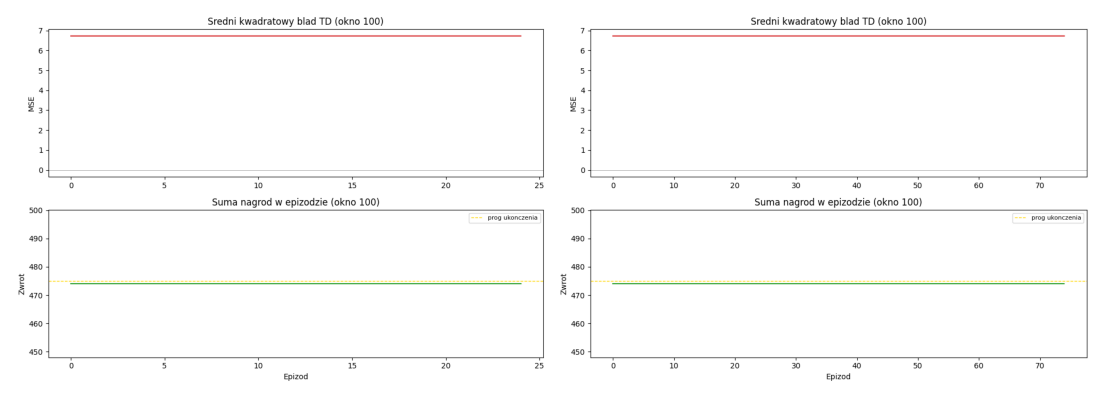

In [68]:
prefix = "cartpole_separete_networks_3\\plots_cartpole"
episodes_grid = [
    [1725, 1775],
]
img_matrix = [[f"{prefix}\\learning_{ep:05d}.png" for ep in row] for row in episodes_grid]
plot_image_matrix(img_matrix, figsize=(14, 10))

Słabo widać ale po restarcie uczenie osiągnęło wyznaczony próg ukończenia

#### Porównanie modeli: wspólne vs osobne wagi

**Wykresy uczenia.** Dla architektury ze **współdzielonym trzonem** obrazki z treningu nadal pokazują **stabilny** obraz: średnia nagroda w oknie rośnie w stronę progu „solved”, błąd TD po początkowych fluktuacjach się ustala — polityka i wartościowanie wyraźnie „doganiają” CartPole.

**Osobne trzonki (`actor_fc*` / `critic_fc*`) — kilka runów.** Okazało się, że **można** wytrenować agenta także przy rozdzielonych wagach, ale proces jest **wyraźnie niestabilniejszy** niż przy jednym trzonie: częściej pojawiają się długie plateau, cofnięcia średniej nagrody lub brak zbieżności w limicie epizodów. Zapisy **`cartpole_separate_networks`** (run **_1**) oraz **`cartpole_separate_networks_2`** (**_2**) zakończyły się **niepowodzeniem** w sensie sensownych krzywych i końcowego modelu — przy **_2** trening był szczególniej nieregularny (m.in. **wznowienie od** `cartpole_checkpoint_ep1600.keras`, gdy po pierwszym podejściu nagroda dopiero zaczęła rosnąć). Trzeci przebieg, **`cartpole_separate_networks_3`** (**_3**), jest już **udany**: wykresy i test krytyka zbliżają się do jakości typowej dla dobrego treningu ze wspólnym trzonem.

**Wniosek:** rozdzielenie aktora i krytyka **nie wyklucza** osiągnięcia progu „solved”, ale **zwiększa wariancję** między uruchomieniami — częściej potrzebny jest **retry**, **resume z checkpointu** albo zmiana seeda / hiperparametrów; przy jednym szczęśliwym runie (**_3**) efekt końcowy jest porównywalny z udanym modelem ze wspólną reprezentacją.


**Test krytyka (`--check-critic`).**

```powershell
python solution.py --env cartpole --check-critic cartpole_single_network\cartpole_final.keras
python solution.py --env cartpole --check-critic cartpole_separate_networks_3\cartpole_final.keras
```

Poniżej **porównanie obok siebie**: sieć ze **wspólnym trzonem** oraz **udany** run z rozłącznymi tronkami (`cartpole_separate_networks_3`). Ten sam wektor `s` w obu kolumnach (`CRITIC_PROBE_STATES`):

| Stan | `cartpole_single_network` | `cartpole_separate_networks_3` |
|-|-|-|
| Pion, zerowe prędkości (środek) | 99.99 | 100.00 |
| Szybkie przechylenie (duża prędkość kątowa) | 13.15 | 37.93 |
| Wózek blisko prawej krawędzi (x ≈ +2.35) | 38.35 | 99.99 |
| Wózek blisko lewej krawędzi (x ≈ −2.35) | 97.16 | 100.00 |
| Pochylony pręt, spokojny wózek | 99.99 | 100.00 |

*(Wartości zaokrąglone do logów z terminala; nieudane przebiegi z osobnymi trzonami — _1 / _2 — pominięte w tabeli, żeby zestawienie czytało się jak „dobre vs dobre”.)*

**Interpretacja:** W obu kolumnach widać **tę samą hierarchię na najtrudniejszej próbce**: wyraźnie **niższe** V(s) przy szybkim przechyleniu (kąt + duża prędkość kątowa) niż przy stabilnym pionie — typowe dla krytyka po sensownym uczeniu. Pozostałe stany mają w obu modelach **wysokie** V(s); dokładne liczby **nie muszą się pokrywać** punktowo (np. prawa krawędź ~38 vs ~100), bo funkcja V jest **aproksymowana**, a rozkład stanów w treningu był inny — ważne jest, że **separate_3** (udany run z osobnymi tronkami) daje profil **porównywalny jakościowo** do `single_network`, a nie jednocyfrowe wartości jak w nieudanych runach _1/_2. Nieudane przebiegi pominięto w tabeli celowo — szczegóły we wcześniejszej dyskusji.

### Inne wymiary sieci (32 x 32)

Dla stabilności porównania uruchamiam trening **tylko** przy architekturze ze **współdzielonym trzonem**

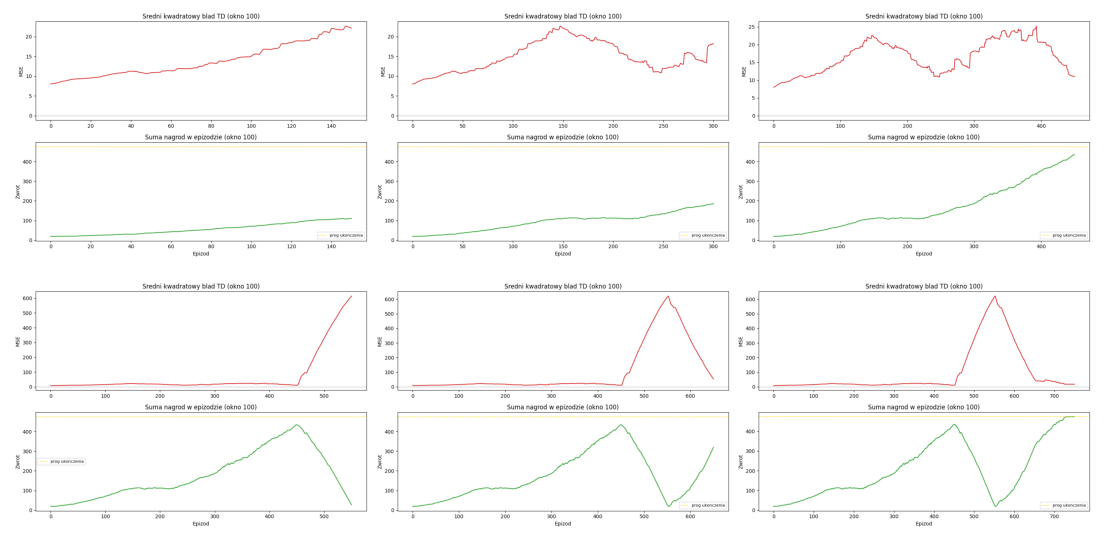

In [ ]:
prefix = "cartpole_single_network_small/plots_cartpole"
episodes_grid = [
    [250, 400, 550],
    [650, 750, 850],
]
img_matrix = [[f"{prefix}/learning_{ep:05d}.png" for ep in row] for row in episodes_grid]

plot_image_matrix(img_matrix, figsize=(14, 7))

Na problem CartPole **wygląda na to, że mniejsza sieć jest wystarczająca**: Dodatkowo czas treningu był krótszy sieć pomimo nagłego spadku, uczyła się stabilniej w początkowych etapach, a także bardzo szybko podniosła się po nagłym spadku

### Inny krok uczący (0.001 -> 0.01) (1e-3 -> 1e-2)

można by się spodziewać standardowych rzeczy, w teori powinno przyśpieszyć uczenie ALE także zmniejszyć jego stabilność
robiąc większe kroki jednocześniej szybciej możemy dotrzeć do celu, jak się od niego oddalać
a może nawet nie byś w stanie wstąpić do minimum lokalnego